In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv("../Using z score method/placement.csv")

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
# checking for skewness 

df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [5]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [6]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

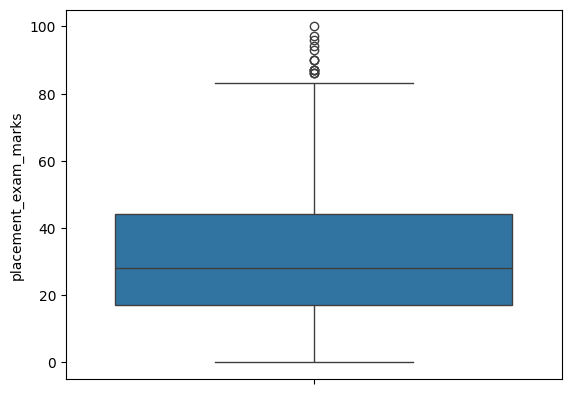

In [7]:
# box plot to see the outliers 

sns.boxplot(df["placement_exam_marks"])

In [9]:
# finding the iqr

percentile_25 = df['placement_exam_marks'].quantile(0.25)
percentile_75 = df['placement_exam_marks'].quantile(0.75)


In [12]:
IQR = percentile_75 - percentile_25

In [13]:
IQR

np.float64(27.0)

In [14]:
upperLimit = percentile_25 + (1.5*IQR)
lowerLimit = percentile_75 - (1.5 * IQR)

In [15]:
print(f"the upper and lower limit are :{upperLimit} and {lowerLimit}")

the upper and lower limit are :57.5 and 3.5


In [16]:
# finding the outliers

df[df["placement_exam_marks"] < upperLimit]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
993,6.73,21.0,1
995,8.87,44.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [17]:
# triming 

new_df = df[df["placement_exam_marks"] < upperLimit]

In [19]:
new_df.shape

(886, 3)

In [24]:
# capping 
new_df_cpy = df.copy()

new_df_cpy['placement_exam_marks'] = np.where(new_df_cpy['placement_exam_marks'] > upperLimit,
    upperLimit,
    np.where(
        new_df_cpy['placement_exam_marks'] < lowerLimit,
        lowerLimit,
        new_df_cpy['placement_exam_marks']
    ))

In [28]:
new_df_cpy.shape

(1000, 3)